# Загружаем данные, проводим обучение

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Загрузка данных
data = pd.read_csv('/content/dataset_for_CC50_962.csv')

# Разделение на признаки и целевую переменную
X = data.drop('CC50, mM', axis=1)
y = data['CC50, mM']

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Будем пробовать обучать модели Random Forest, Gradient Boosting, XGBoost, SVR с перебором гиперпараметров. У части моделей сначала проведем отбор признаков

In [20]:
#Данные будем хравить в словаре
results = {}
scoring = 'r2'

In [21]:
#Модель Random Forest
model_rf = RandomForestRegressor(n_estimators=50, random_state=42)

# Создаем пайплайн
pipe_rf = Pipeline([
    ('scaler', StandardScaler()),    # Шаг 1: Стандартизация
    ('rf', model_rf)                 # Шаг 2: Финальная модель
])

params_rf = {
    'rf__n_estimators': [10, 30, 50],
    'rf__max_depth': [20, 30, 50],
}

grid_rf = GridSearchCV(pipe_rf, params_rf, cv=10, scoring=scoring)

grid_rf.fit(X_train, y_train)
y_pred_rf = grid_rf.best_estimator_.predict(X_test)
results['Random Forest'] = {
    'MAPE': mean_absolute_percentage_error(y_test, y_pred_rf),
    'R2': r2_score(y_test, y_pred_rf),
    'MSE': mean_squared_error(y_test, y_pred_rf)
}


In [22]:
#Градиентный бустинг
model_gb = GradientBoostingRegressor(random_state=42)


pipe_gb = Pipeline([
    ('scaler', StandardScaler()),
    ('gb', model_gb)
])

params_gb = {
    'gb__n_estimators': [250, 300, 350],
    'gb__learning_rate': [0.05, 0.1, 0.2]
}

grid_gb = GridSearchCV(pipe_gb, params_gb, cv=10, scoring=scoring)
grid_gb.fit(X_train, y_train)
y_pred_gb = grid_gb.best_estimator_.predict(X_test)
results['Gradient Boosting'] = {
    'MAPE': mean_absolute_percentage_error(y_test, y_pred_gb),
    'R2': r2_score(y_test, y_pred_gb),
    'MSE': mean_squared_error(y_test, y_pred_gb)
}

In [26]:
# XGBoost
model_xgb = XGBRegressor(random_state=42, eval_metric='logloss')

# Создаем пайплайн
pipe_xgb = Pipeline([
    ('scaler', StandardScaler()),      # Шаг 1: Стандартизация
    ('xgb', model_xgb)                 # Шаг 2: Финальная модель
])

params_xgb = {
    'xgb__n_estimators': [150, 200, 250],
    'xgb__learning_rate': [0.05, 0.1, 0.2]
}

grid_xgb = GridSearchCV(pipe_xgb, params_xgb, cv=10, scoring=scoring)

grid_xgb.fit(X_train, y_train)
y_pred_xgb = grid_xgb.best_estimator_.predict(X_test)
results['XGBoost'] = {
    'MAPE': mean_absolute_percentage_error(y_test, y_pred_xgb),
    'R2': r2_score(y_test, y_pred_xgb),
    'MSE': mean_squared_error(y_test, y_pred_xgb)
}



In [23]:
#SVR
pipe_svr = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR()),
])

params_svr = {
    'svr__C': [40, 50, 100],
    'svr__epsilon': [0.005, 0.01, 0.05],
}
grid_svr = GridSearchCV(pipe_svr, params_svr, cv=10, scoring=scoring)

grid_svr.fit(X_train, y_train)
y_pred_svr = grid_svr.best_estimator_.predict(X_test)
results['SVR'] = {
    'MAPE': mean_absolute_percentage_error(y_test, y_pred_svr),
    'R2': r2_score(y_test, y_pred_svr),
    'MSE': mean_squared_error(y_test, y_pred_svr)
}

In [37]:
#Сравним метрики
print(f"{'Model':<20} | {'MAPE':<8} | {'R2':<6} | {'MSE':<8}")
for model, metrics in results.items():
    print(f"{model:<20} | {metrics['MAPE']:.4f} | {metrics['R2']:.4f} | {metrics['MSE']:.4f}")


Model                | MAPE     | R2     | MSE     
Random Forest        | 4.4683 | 0.5070 | 113410.9879
Gradient Boosting    | 4.1005 | 0.5293 | 108290.4872
SVR                  | 4.8078 | 0.3052 | 159846.5615
XGBoost              | 3.3850 | 0.4975 | 115598.0791
Random Forest log-transformed | 1.6214 | 0.3671 | 145587.3268
Gradient Boosting log-transformed | 1.5931 | 0.4072 | 136378.7300
XGBoost log-transformed | 1.6555 | 0.4346 | 130073.5628
SVR log-transformed  | 2.3326 | -0.0613 | 244153.8251


У моделей получилось неудовлетворительные метрики.

# Обучение на прологарифмированных данных

Так как при подготовке EDA мы предположили, что распределение исходных данных по таргетному признаку СC50 является лог-нормальным и обучение на обработанных "исходных" данных дает неудовлетворительные результаты, проверим распределение на прологарифмированных данных по таргетному признаку.

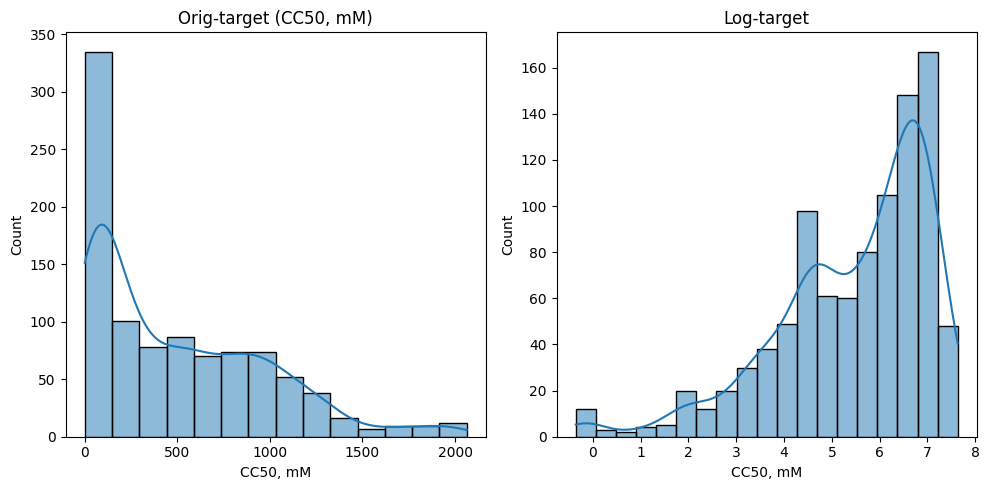

In [32]:
y_log = np.log(y + 1e-10)

#Посмотрим на распределение визуально
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.histplot(y, kde=True)
plt.title('Orig-target (СC50, mM)')

plt.subplot(1, 2, 2)
sns.histplot(y_log, kde=True)
plt.title('Log-target')

plt.tight_layout()
plt.show()

Так как логарифм-таргет выглядит лучше, попробуем провести обучение на нем. Оценки метрик будем проводить в исходном масштабе данных.

In [33]:
#Поделим выборку с учетом лог-целевой переменной на обучающую и тестовую выборки
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

In [34]:
# Вычисляем коэффициент детерминации R² после обратного преобразования логарифма
def custom_r2_scorer(model, features, target_log):
    predictions_log = model.predict(features)
    true_values = np.exp(target_log)
    predicted_values = np.exp(predictions_log)
    return r2_score(true_values, predicted_values)


# Вычисляем среднюю абсолютную процентную ошибку (MAPE) после обратного преобразования логарифма
def custom_mape_scorer(model, features, target_log):
    predictions_log = model.predict(features)
    true_values = np.exp(target_log)
    predicted_values = np.exp(predictions_log)
    return mean_absolute_percentage_error(true_values, predicted_values)


# Вычисляем среднеквадратичную ошибку (MSE) после обратного преобразования логарифма
def custom_mse_scorer(model, features, target_log):
    predictions_log = model.predict(features)
    true_values = np.exp(target_log)
    predicted_values = np.exp(predictions_log)
    return mean_squared_error(true_values, predicted_values)

Еще раз обучим модели, но уже на логарифмированных данных. Для скоринга ипользуем каэф.детерминации

In [35]:
# Random Forest
grid_rf = GridSearchCV(pipe_rf, params_rf, cv=10, scoring=custom_r2_scorer)

grid_rf.fit(X_train, y_train_log)

# Gradient Boosting
grid_gb = GridSearchCV(pipe_gb, params_gb, cv=10, scoring=custom_r2_scorer)

grid_gb.fit(X_train, y_train_log)

# XGBoost
grid_xgb = GridSearchCV(pipe_xgb, params_xgb, cv=10, scoring=custom_r2_scorer)

grid_xgb.fit(X_train, y_train_log)

# Support Vector Regressor
grid_svr = GridSearchCV(pipe_svr, params_svr, cv=10, scoring=custom_r2_scorer)

grid_svr.fit(X_train, y_train_log)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svr', SVR())]),
             param_grid={'svr__C': [40, 50, 100],
                         'svr__epsilon': [0.005, 0.01, 0.05]},
             scoring=<function custom_r2_scorer at 0x79baa795aa20>)

In [55]:
results['Random Forest log-transformed'] = {
    'MAPE':custom_mape_scorer(grid_rf.best_estimator_, X_test, y_test_log),
    'R2': custom_r2_scorer(grid_rf.best_estimator_, X_test, y_test_log),
    'MSE': custom_mse_scorer(grid_rf.best_estimator_, X_test, y_test_log),
}

results['Gradient Boosting log-transformed'] = {
    'MAPE': custom_mape_scorer(grid_gb.best_estimator_, X_test, y_test_log),
    'R2': custom_r2_scorer(grid_gb.best_estimator_, X_test, y_test_log),
    'MSE': custom_mse_scorer(grid_gb.best_estimator_, X_test, y_test_log),
}

results['XGBoost log-transformed'] = {
    'MAPE':custom_mape_scorer(grid_xgb.best_estimator_, X_test, y_test_log),
    'R2': custom_r2_scorer(grid_xgb.best_estimator_, X_test, y_test_log),
    'MSE':custom_mse_scorer(grid_xgb.best_estimator_, X_test, y_test_log),
}

results['SVR log-transformed'] = {
    'MAPE': custom_mape_scorer(grid_svr.best_estimator_, X_test, y_test_log),
    'R2': custom_r2_scorer(grid_svr.best_estimator_, X_test, y_test_log),
    'MSE': custom_mse_scorer(grid_svr.best_estimator_, X_test, y_test_log),
}

In [56]:
# Вывод результатов
print(f"{'Model':<40} | {'MAPE':<8} | {'R2':<6} | {'MSE':<8}")
for model, metrics in results.items():
    print(f"{model:<40} | {metrics['MAPE']:.4f} | {metrics['R2']:.4f} | {metrics['MSE']:.4f}")

Model                                    | MAPE     | R2     | MSE     
Random Forest                            | 4.4683 | 0.5070 | 113410.9879
Gradient Boosting                        | 4.1005 | 0.5293 | 108290.4872
SVR                                      | 4.8078 | 0.3052 | 159846.5615
XGBoost                                  | 3.3850 | 0.4975 | 115598.0791
Random Forest log-transformed            | 1.6214 | 0.3671 | 145587.3268
Gradient Boosting log-transformed        | 1.5931 | 0.4072 | 136378.7300
XGBoost log-transformed                  | 1.6555 | 0.4346 | 130073.5628
SVR log-transformed                      | 2.3326 | -0.0613 | 244153.8251
XGBoost filtered                         | 1.7206 | 0.3805 | 142517.0987
XGBoost tuned                            | 1.6555 | 0.4346 | 130073.5628


По результатам метрик качество обучение не стало лучше.

# Сравнение результатов нелог и лог данных

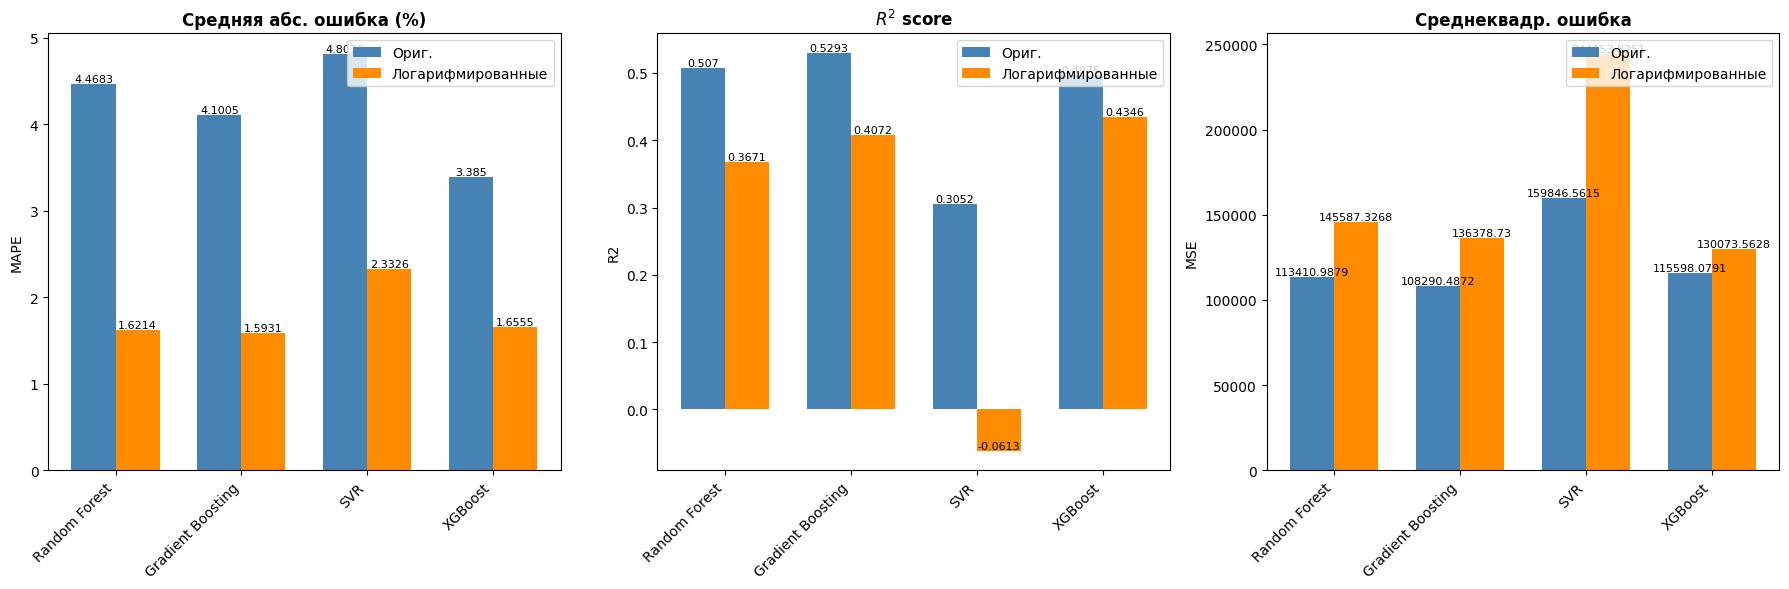

In [41]:
# Фильтруем модели с лог-преобразованиями и без
models_log = {name: data for name, data in results.items() if 'log' in name.lower()}
models_raw = {name: data for name, data in results.items() if 'log' not in name.lower()}

metrics = ['MAPE', 'R2', 'MSE']
titles = ['Средняя абс. ошибка (%)', '$R^2$ score', 'Среднеквадр. ошибка']

labels = list(models_raw.keys())
positions = np.arange(len(labels))
bar_width = 0.35  # Ширина одного столбика
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

for idx, metric in enumerate(metrics):
    ax = axes[idx]

    # Собираем значения метрики для обеих групп моделей
    raw_values = [models_raw[name][metric] for name in labels]
    log_values = [models_log.get(name + ' log-transformed', {}).get(metric, 0) for name in labels]

    bars_original = ax.bar(positions - bar_width/2, raw_values, bar_width, label='Ориг.', color='steelblue')
    bars_transformed = ax.bar(positions + bar_width/2, log_values, bar_width, label='Логарифмированные', color='darkorange')



    ax.set_ylabel(metric)
    ax.set_title(titles[idx], fontweight='bold')
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)
    ax.legend(loc='upper right', frameon=True)

    def add_labels(bars):
        for bar in bars:
            value = round(bar.get_height(), 4)
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                   str(value), ha='center', va='bottom', fontsize=8)

    add_labels(bars_original)
    add_labels(bars_transformed)

plt.tight_layout()
plt.show()

Хотя лучший R2 показал Random Forest на нелогарифмированном таргете, По совокупности метрик лучшие результаты показал XGBoost.

In [42]:
#Определим важность признаков
importances = grid_xgb.best_estimator_['xgb'].feature_importances_
importances

array([6.90826331e-04, 0.00000000e+00, 1.98251614e-03, 3.45578766e-03,
       1.26379135e-03, 3.21038091e-03, 2.74368632e-03, 1.83262024e-03,
       0.00000000e+00, 1.09647610e-03, 0.00000000e+00, 2.66903779e-03,
       1.57327717e-03, 1.08927640e-03, 1.42051000e-03, 2.73765181e-03,
       1.86740863e-03, 3.61017650e-03, 2.22121319e-03, 4.15495178e-03,
       2.62153801e-03, 5.93444705e-03, 8.86728801e-03, 1.28868353e-02,
       7.00185588e-03, 3.06563675e-02, 5.04367705e-03, 3.43166315e-03,
       1.62225403e-03, 4.53774992e-04, 2.47790455e-03, 7.14178337e-03,
       1.02077285e-03, 7.08432542e-03, 1.09904725e-03, 6.90961350e-03,
       2.63216277e-03, 7.89094344e-03, 1.01514338e-02, 3.11051495e-03,
       6.26867451e-03, 5.13598556e-03, 9.94112343e-03, 3.25452685e-02,
       7.23225158e-03, 6.02349732e-03, 1.99837517e-03, 2.26881518e-03,
       3.11326212e-03, 3.21110641e-03, 9.51564405e-04, 2.08241120e-02,
       9.61987243e-04, 1.03534211e-03, 1.39600609e-03, 8.43476783e-03,
      

Видим, что есть признаки с 0 важностью. Попробуем убрать их

In [44]:
feature_names = X.columns
# Порог для важности (можно использовать 0 или малое число, например 1e-5)
threshold = 0.0

important_indices = np.where(importances > threshold)[0]
important_features = feature_names[important_indices]

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

#Выведем наиболее важные признаки
top_features = feature_importance_df.sort_values(by='Importance', ascending=False)
print(top_features.head(10))


                     Feature  Importance
107                NHOHCount    0.106916
115            NumHAcceptors    0.098394
113  NumAromaticHeterocycles    0.040257
114         NumAromaticRings    0.039638
43                    Kappa1    0.032545
25              BCUT2D_MRLOW    0.030656
111        NumAliphaticRings    0.023603
176                fr_ketone    0.022772
51                PEOE_VSA13    0.020824
124                    MolMR    0.019829


# Итоговое обучение

Попробуем провести обучение на наиболее важных признаках

In [45]:
X_train_imp = X_train[important_features]
X_test_imp = X_test[important_features]

In [46]:
grid_xgb.best_params_

{'xgb__learning_rate': 0.05, 'xgb__n_estimators': 200}

Вновь поподбираем гиперпараметры в области вокруг лучших из предыдущего подхода.


In [57]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBRegressor(random_state=42))
])

param_grid = {
    'model__n_estimators': [100, 150, 200, 250, 300],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.07]
}

# GridSearch
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=r2_exp_scorer,
    cv=10,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_imp, y_train_log)

Fitting 10 folds for each of 20 candidates, totalling 200 fits


GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model',
                                        XGBRegressor(base_score=None,
                                                     booster=None,
                                                     callbacks=None,
                                                     colsample_bylevel=None,
                                                     colsample_bynode=None,
                                                     colsample_bytree=None,
                                                     device=None,
                                                     early_stopping_rounds=None,
                                                     enable_categorical=False,
                                                     eval_metric=None,
                                                     feature_types=None,
                                                     feature_weights=None,
                                                     gamma=None,
                                                     grow_policy=...
                                                     max_delta_step=None,
                                                     max_depth=None,
                                                     max_leaves=None,
                                                     min_child_weight=None,
                                                     missing=nan,
                                                     monotone_constraints=None,
                                                     multi_strategy=None,
                                                     n_estimators=None,
                                                     n_jobs=None,
                                                     num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.01, 0.03, 0.05, 0.07],
                         'model__n_estimators': [100, 150, 200, 250, 300]},
             scoring=<function r2_exp_scorer at 0x79baa7bbab60>, verbose=1)

In [58]:
results['XGBoost filtered'] = {
    'MAPE': custom_mape_scorer(grid_search.best_estimator_, X_test_imp, y_test_log),
    'R2': custom_r2_scorer(grid_search.best_estimator_, X_test_imp, y_test_log),
    'MSE': mse_exp_scorer(grid_search.best_estimator_, X_test_imp, y_test_log),
}

In [59]:
#Обучим новую модель на обновившихся условиях
grid_search.fit(X_train, y_train_log)

Fitting 10 folds for each of 20 candidates, totalling 200 fits


GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model',
                                        XGBRegressor(base_score=None,
                                                     booster=None,
                                                     callbacks=None,
                                                     colsample_bylevel=None,
                                                     colsample_bynode=None,
                                                     colsample_bytree=None,
                                                     device=None,
                                                     early_stopping_rounds=None,
                                                     enable_categorical=False,
                                                     eval_metric=None,
                                                     feature_types=None,
                                                     feature_weights=None,
                                                     gamma=None,
                                                     grow_policy=...
                                                     max_delta_step=None,
                                                     max_depth=None,
                                                     max_leaves=None,
                                                     min_child_weight=None,
                                                     missing=nan,
                                                     monotone_constraints=None,
                                                     multi_strategy=None,
                                                     n_estimators=None,
                                                     n_jobs=None,
                                                     num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.01, 0.03, 0.05, 0.07],
                         'model__n_estimators': [100, 150, 200, 250, 300]},
             scoring=<function r2_exp_scorer at 0x79baa7bbab60>, verbose=1)

In [60]:
results['XGBoost tuned'] = {
    'MAPE': custom_mape_scorer(grid_search.best_estimator_, X_test, y_test_log),
    'R2': custom_r2_scorer(grid_search.best_estimator_, X_test, y_test_log),
    'MSE': mse_exp_scorer(grid_search.best_estimator_, X_test, y_test_log),
}

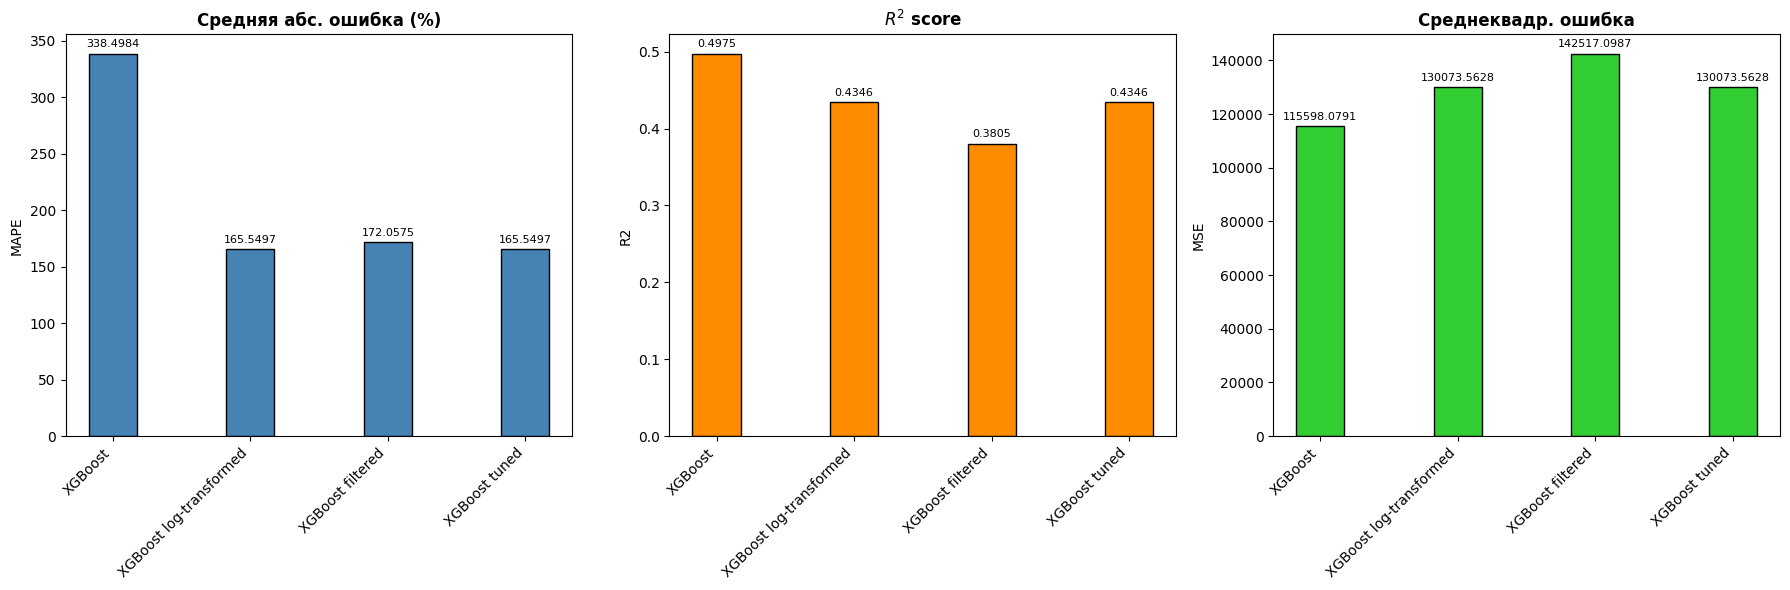

In [61]:
model_names = ['XGBoost', 'XGBoost log-transformed', 'XGBoost filtered', 'XGBoost tuned']

metrics = ['MAPE', 'R2', 'MSE']
titles = ['Средняя абс. ошибка (%)', '$R^2$ score', 'Среднеквадр. ошибка']

bar_width = 0.35
positions = np.arange(len(model_names))
fig, axes = plt.subplots(ncols=3, figsize=(18, 6))


# Формируем гистограммы для каждой метрики
for idx, (ax, metric, title) in enumerate(zip(axes, metrics, titles)):
    colors = ['steelblue', 'darkorange', 'limegreen']
    values = [results[name].get(metric, 0) * 100 if metric == 'MAPE' else results[name].get(metric, 0) for name in model_names]

    bars = ax.bar(positions, values, bar_width, color=colors[idx % len(colors)], edgecolor='black')


    ax.set_ylabel(metric)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(positions)
    ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=10)

    def annotate_bars(bars):
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.4f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8)

    annotate_bars(bars)

plt.tight_layout()
plt.show()